In [172]:
import pandas as pd
import numpy as np

In [173]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)

nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [174]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [175]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [176]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [177]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

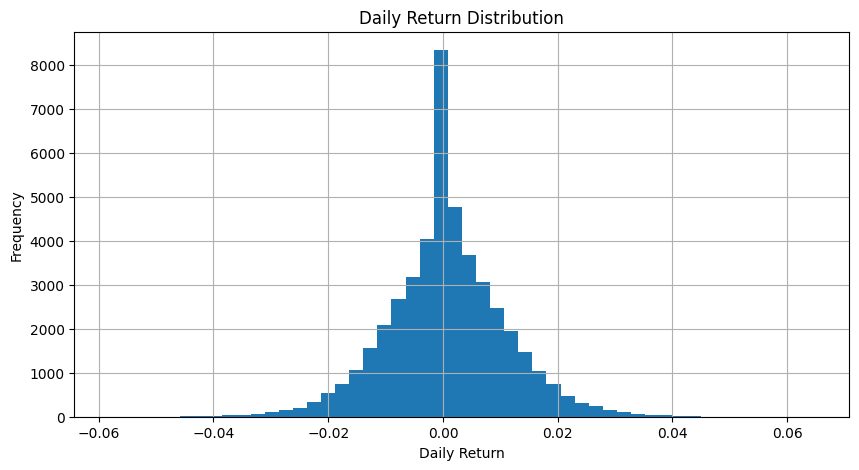

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

nav["daily_return"].hist(
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [179]:
# Create empty list
cagr_results = []

# Process each fund separately
for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] -
         fund_data.iloc[0]["date"]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append([
        fund,
        round(cagr, 2)
    ])

# Convert to DataFrame
cagr_table = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_table.head()

,amfi_code,cagr_pct
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [180]:
cagr_table.sort_values(
    "cagr_pct",
    ascending=False
).head(10)

,amfi_code,cagr_pct
25,120505,32.83
21,119598,32.42
39,149324,32.29
36,148569,31.95
34,148567,30.97
30,120843,30.91
2,100033,30.12
38,149323,29.58
16,119094,28.21
19,119551,25.80


In [181]:
cagr_table.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

print("CAGR table saved successfully")

CAGR table saved successfully


## CAGR Analysis

CAGR provides a standardized measure of annualized growth across mutual funds. Higher CAGR values indicate stronger long-term wealth creation potential.

In [182]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    std_return = fund_returns.std()

    sharpe = (
        (avg_return - (rf / 252))
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        round(sharpe, 4)
    ])

sharpe_table = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_table.head()

,amfi_code,sharpe_ratio
0,100016,-0.2015
1,100025,-0.5671
2,100033,1.0937
3,101206,1.0272
4,101207,0.1627


In [183]:
sharpe_table.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio
34,148567,1.4483
30,120843,1.3067
36,148569,1.2349
19,119551,1.2083
25,120505,1.1801
38,149323,1.1321
2,100033,1.0937
9,118632,1.0817
3,101206,1.0272
24,120504,1.0265


In [184]:
sharpe_table.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio file saved")

Sharpe Ratio file saved


## Sharpe Ratio Analysis

Sharpe Ratio measures risk-adjusted performance. Funds with higher Sharpe Ratios generated superior returns relative to the volatility experienced by investors.

In [185]:
rf = 0.065

sortino_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    # Negative returns only
    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = downside_returns.std()

    sortino = (
        (avg_return - (rf / 252))
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append([
        fund,
        round(sortino, 4)
    ])

sortino_table = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_table.head()

,amfi_code,sortino_ratio
0,100016,-0.3510
1,100025,-0.9418
2,100033,1.8291
3,101206,1.7996
4,101207,0.2766


In [186]:
sortino_table.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio
34,148567,2.3856
30,120843,2.3643
36,148569,2.1469
19,119551,2.1403
25,120505,2.0294
38,149323,1.8751
9,118632,1.8501
2,100033,1.8291
24,120504,1.8053
3,101206,1.7996


In [187]:
sortino_table.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio file saved")

Sortino Ratio file saved


## Sortino Ratio Analysis

Sortino Ratio evaluates fund performance by considering only downside risk. Funds with high Sortino Ratios delivered strong returns while minimizing negative return periods.

In [188]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [189]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [190]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [191]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    # Fund data
    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    # Merge with benchmark
    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 10:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        alpha = (
            regression.intercept * 252
        )

        alpha_beta_results.append([
            fund,
            round(alpha, 4),
            round(beta, 4)
        ])

In [192]:
alpha_beta = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653


In [193]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


In [194]:
alpha_beta.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta
21,119598,0.3034,-0.0232
39,149324,0.3006,0.0115
25,120505,0.2926,0.0005
36,148569,0.2827,0.0181
30,120843,0.2733,-0.0228
2,100033,0.2720,0.0051
34,148567,0.2698,0.0237
38,149323,0.2660,-0.0025
16,119094,0.2608,-0.0663
19,119551,0.2320,-0.0318


In [195]:
alpha_beta.sort_values(
    "beta",
    ascending=False
).head(10)

,amfi_code,alpha,beta
11,118634,0.1750,0.1035
22,119599,0.0488,0.0620
32,125497,0.1773,0.0488
26,120506,0.1625,0.0419
28,120841,0.1304,0.0364
15,119093,0.0823,0.0259
34,148567,0.2698,0.0237
3,101206,0.2140,0.0211
36,148569,0.2827,0.0181
29,120842,0.0780,0.0181


## Alpha & Beta Analysis

Alpha measures a fund's ability to generate excess returns beyond market expectations, while Beta measures sensitivity to market movements. Funds with positive Alpha and moderate Beta are generally attractive for long-term investors.

In [196]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    # Running maximum NAV
    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    mdd_results.append([
        fund,
        round(max_dd * 100, 2)
    ])

In [197]:
mdd_table = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown_pct"
    ]
)

mdd_table.head()

,amfi_code,max_drawdown_pct
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [198]:
mdd_table.sort_values(
    "max_drawdown_pct"
).head(10)

,amfi_code,max_drawdown_pct
22,119599,-52.57
17,119095,-51.68
4,101207,-35.45
39,149324,-31.17
21,119598,-28.71
7,102886,-28.00
0,100016,-24.73
29,120842,-24.00
11,118634,-23.34
15,119093,-21.75


In [199]:
mdd_table.sort_values(
    "max_drawdown_pct",
    ascending=False
).head(10)

,amfi_code,max_drawdown_pct
27,120507,-0.10
31,120844,-0.12
5,101208,-0.16
1,100025,-4.31
18,119120,-4.33
13,118636,-8.32
6,102885,-10.86
34,148567,-11.27
3,101206,-11.29
12,118635,-11.65


In [200]:
mdd_table.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully")

max_drawdown.csv saved successfully


In [201]:
for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    print(
        fund,
        worst_row["date"],
        round(worst_row["drawdown"] * 100, 2)
    )

100016 2022-09-15 00:00:00 -24.73
100025 2023-07-28 00:00:00 -4.31
100033 2022-05-12 00:00:00 -16.22
101206 2023-07-05 00:00:00 -11.29
101207 2026-05-11 00:00:00 -35.45
101208 2023-09-12 00:00:00 -0.16
102885 2022-03-29 00:00:00 -10.86
102886 2026-04-27 00:00:00 -28.0
102887 2022-07-04 00:00:00 -21.54
118632 2024-07-19 00:00:00 -17.41
118633 2024-02-29 00:00:00 -18.63
118634 2026-02-20 00:00:00 -23.34
118635 2022-06-09 00:00:00 -11.65
118636 2024-02-09 00:00:00 -8.32
119092 2025-02-07 00:00:00 -14.4
119093 2023-05-22 00:00:00 -21.75
119094 2022-08-11 00:00:00 -20.96
119095 2026-05-11 00:00:00 -51.68
119120 2025-04-01 00:00:00 -4.33
119551 2024-02-05 00:00:00 -15.01
119552 2024-09-02 00:00:00 -11.8
119598 2025-05-14 00:00:00 -28.71
119599 2025-10-28 00:00:00 -52.57
120503 2023-11-09 00:00:00 -13.9
120504 2023-05-30 00:00:00 -12.59
120505 2025-01-23 00:00:00 -18.19
120506 2023-08-14 00:00:00 -19.83
120507 2025-10-20 00:00:00 -0.1
120841 2025-02-14 00:00:00 -17.57
120842 2024-10-17 00:00:

## Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline experienced by a fund from its historical peak. Funds with smaller drawdowns demonstrate better downside protection during market stress periods.

In [202]:
performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

sharpe = pd.read_csv(
    "../data/processed/sharpe_ratio.csv"
)

alpha_beta = pd.read_csv(
    "../data/processed/alpha_beta.csv"
)

mdd = pd.read_csv(
    "../data/processed/max_drawdown.csv"
)

In [203]:
scorecard = performance.merge(
    sharpe,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd,
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,std_dev_ann_pct,max_drawdown_pct_x,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,sharpe_ratio_y,alpha_y,beta_y,max_drawdown_pct_y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14.0,-21.70,14288,1.54,4,Moderate,1.2083,0.2320,-0.0318,-15.01
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,14.0,-24.43,1231,0.66,3,Moderate,0.9533,0.1987,-0.0262,-11.80
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,25.0,-13.35,19259,1.43,5,Very High,0.9453,0.3034,-0.0232,-28.71
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,25.0,-24.78,36061,0.72,4,Very High,-0.0572,0.0488,0.0620,-52.57
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,4.0,-2.30,24101,0.77,5,Low,-0.2266,0.0562,-0.0064,-4.33


In [204]:
# Create ranking columns

scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_y"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_y"]
    .rank(pct=True)
)

# Lower expense ratio is better
scorecard["expense_rank"] = (
    1 -
    scorecard["expense_ratio_pct"]
    .rank(pct=True)
)

# Smaller drawdown is better
scorecard["drawdown_rank"] = (
    1 -
    scorecard["max_drawdown_pct_y"]
    .rank(pct=True)
)

# Calculate final score
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = scorecard["fund_score"].round(2)

# View Top 10 Funds
top_funds = scorecard.sort_values(
    "fund_score",
    ascending=False
)

top_funds[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head(10)

,amfi_code,scheme_name,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.75
12,120505,ICICI Pru Midcap Fund - Regular - Growth,81.62
39,149324,DSP Small Cap Fund - Regular - Growth,77.31
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.38
22,120843,Kotak Flexicap Fund - Regular - Growth,74.62
26,119094,Axis Midcap Fund - Regular - Growth,69.62
38,149323,DSP Midcap Fund - Regular - Growth,68.38
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,68.12
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,62.38
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,62.06


In [205]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

In [206]:
top_funds = scorecard.sort_values(
    "fund_score",
    ascending=False
)

top_funds[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head(10)

,amfi_code,scheme_name,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.75
12,120505,ICICI Pru Midcap Fund - Regular - Growth,81.62
39,149324,DSP Small Cap Fund - Regular - Growth,77.31
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.38
22,120843,Kotak Flexicap Fund - Regular - Growth,74.62
26,119094,Axis Midcap Fund - Regular - Growth,69.62
38,149323,DSP Midcap Fund - Regular - Growth,68.38
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,68.12
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,62.38
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,62.06


In [207]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


In [208]:
scorecard.sort_values(
    "fund_score",
    ascending=False
)[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
2,SBI Small Cap Fund - Regular Plan - Growth,82.75
12,ICICI Pru Midcap Fund - Regular - Growth,81.62
39,DSP Small Cap Fund - Regular - Growth,77.31
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.38
22,Kotak Flexicap Fund - Regular - Growth,74.62
26,Axis Midcap Fund - Regular - Growth,69.62
38,DSP Midcap Fund - Regular - Growth,68.38
34,Mirae Asset Large Cap Fund - Regular - Growth,68.12
11,ICICI Pru Bluechip Fund - Direct - Growth,62.38
36,Mirae Asset Tax Saver Fund - Regular - Growth,62.06


## Fund Scorecard Analysis

The composite fund score combines return, risk-adjusted performance, alpha generation, cost efficiency, and downside protection. Higher-scoring funds demonstrate strong all-round performance across multiple investment metrics.

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [210]:
top5_funds = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(5)
)

top5_codes = top5_funds["amfi_code"].tolist()

print(top5_codes)

[119598, 120505, 149324, 100033, 120843]


In [211]:
top_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

In [212]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

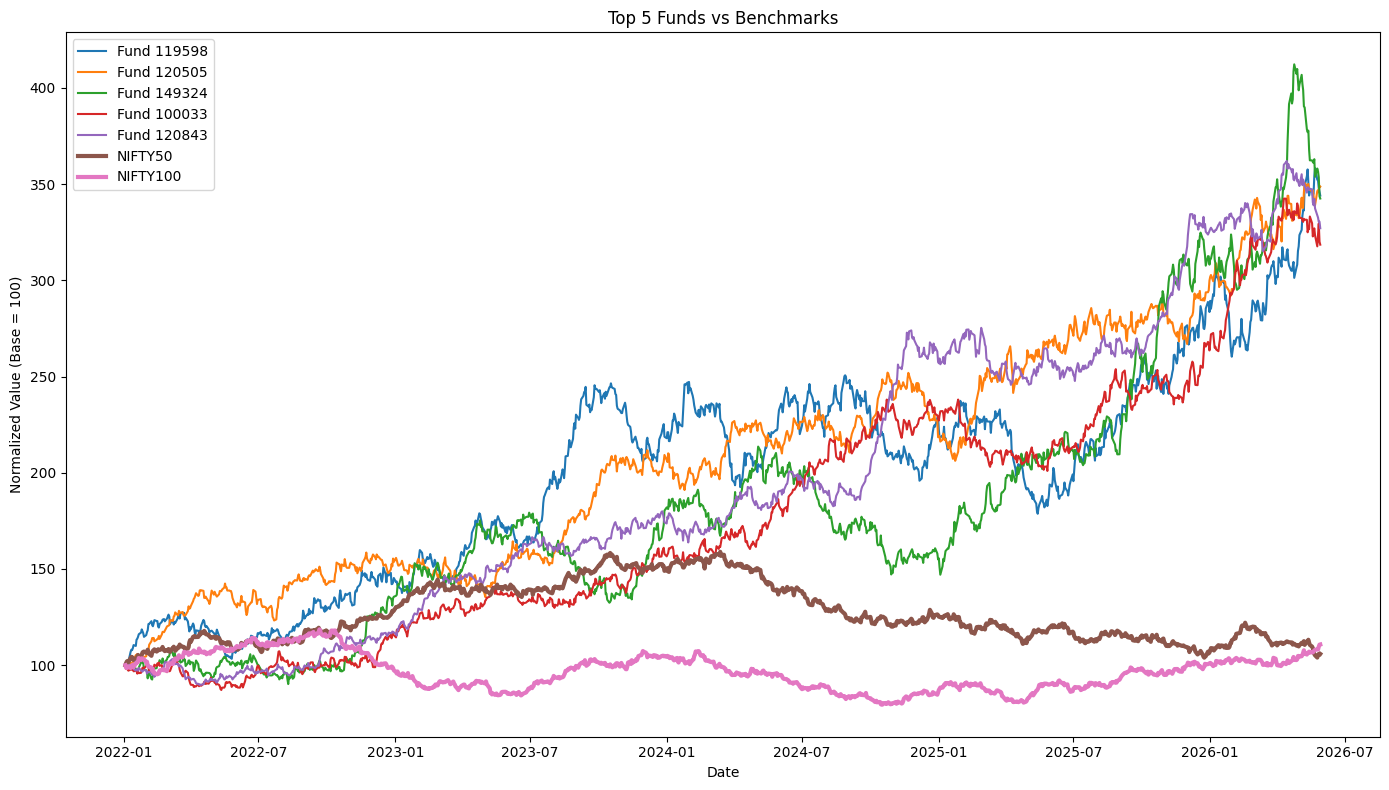

In [213]:
# Normalize Top Funds

plt.figure(figsize=(14,8))

for fund in top5_codes:

    fund_data = (
        top_nav[top_nav["amfi_code"] == fund]
        .sort_values("date")
    )

    normalized = (
        fund_data["nav"]
        / fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        normalized,
        label=f"Fund {fund}"
    )

# Normalize NIFTY50

nifty50_norm = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50_norm,
    linewidth=3,
    label="NIFTY50"
)

# Normalize NIFTY100

nifty100_norm = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100_norm,
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()

In [214]:
# Recreate daily returns
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Tracking Error Calculation
tracking_results = []

# Benchmark returns
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

for fund in top5_codes:

    # Fund data
    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
    )

    # Merge fund and benchmark returns
    merged = pd.merge(
        fund_data[["date", "daily_return"]],
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    # Calculate Tracking Error
    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        ).std()
        * np.sqrt(252)
    )

    tracking_results.append(
        [
            fund,
            round(tracking_error, 4)
        ]
    )

# Create DataFrame
tracking_error_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

# Display result
tracking_error_df

,amfi_code,tracking_error
0,119598,0.2839
1,120505,0.2320
2,149324,0.2792
3,100033,0.2287
4,120843,0.2064


In [215]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


## Benchmark Comparison

The benchmark comparison chart highlights how the top-ranked funds performed relative to NIFTY50 and NIFTY100. Tracking Error measures the consistency of fund returns relative to the benchmark, with lower values indicating closer benchmark tracking.